### **Adeline Makokha**
### **191199**
### **DSA 8401: Applied Machine Learning**
### **Assignment 4: Ensemble Methods**

###1 Goals
This week’s activity focuses on studying of a new group of methods that works very well as an starting
point in most of machine learning projects. The specific goals are:

• Review the pre-processing steps that every project must follow.

• Try two methods: Random Forest (RF) and Gradient Boosting Trees

• Study the influence of different parameters in the correct generalization of a model

### 2 Assignment Description
In this activity we will work with the dataset called “Fetal Health Classification”, which you can found
at https://www.kaggle.com/andrewmvd/fetal-health-classification.

It is requested:

###1. Import the dataset using Pandas. Does it have missings?

In [1]:
# Import packages

import  pandas as pd
import  seaborn as sns
import  matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import auc
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
import warnings
warnings.filterwarnings('ignore')


In [2]:
#loading data from github
url = "https://raw.githubusercontent.com/adeline-pepela/Module-4/main/Applied%20Machine%20Learning/fetal_health.csv"
df = pd.read_csv(url)

In [3]:
#display the first rows of the data
df.head()

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120.0,0.000,0.0,0.000,0.000,0.0,0.0,73.0,0.5,43.0,...,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,2.0
1,132.0,0.006,0.0,0.006,0.003,0.0,0.0,17.0,2.1,0.0,...,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,1.0
2,133.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.1,0.0,...,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,1.0
3,134.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,1.0
4,132.0,0.007,0.0,0.008,0.000,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,1.0


In [4]:
#shape of the data
df.shape

(2126, 22)

The dataset has 2126 rows and 22 columns.

### Observe the dataset attributes and their statistical description.

In [5]:
# Display dataset information
print("\nDataset Info:")
print(df.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 22 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   baseline value                                          2126 non-null   float64
 1   accelerations                                           2126 non-null   float64
 2   fetal_movement                                          2126 non-null   float64
 3   uterine_contractions                                    2126 non-null   float64
 4   light_decelerations                                     2126 non-null   float64
 5   severe_decelerations                                    2126 non-null   float64
 6   prolongued_decelerations                                2126 non-null   float64
 7   abnormal_short_term_variability                         2126 non-null   float64
 8   mean_value_of_short_ter

In [6]:
# Display basic info and check for missing values

missing_values = df.isnull().sum()
missing_values

,0
baseline value,0
accelerations,0
fetal_movement,0
uterine_contractions,0
light_decelerations,0
severe_decelerations,0
prolongued_decelerations,0
abnormal_short_term_variability,0
mean_value_of_short_term_variability,0
percentage_of_time_with_abnormal_long_term_variability,0


After checking for missing values, no missing values were found every column is complete.

### 2. Our objective will be to distinguish subjects with normal fetal status from the rest. What should we do in the data set?

The dataset’s target variable is fetal_health, which takes three classes:

1 = Normal

2 = Suspect

3 = Pathological

Since the objective is to distinguish normal vs. rest, convert this into a binary classification problem.


Relabel the target variable:

Keep 1 (Normal) as 0 (or "Normal").

Convert 2 and 3 into 1 (or "Abnormal").
This way, the new target has only two classes: Normal vs. Abnormal.

In [7]:
# Create a binary target variable: 0 = Normal, 1 = Abnormal (Suspect or Pathological)
df["fetal_health_binary"] = df["fetal_health"].apply(lambda x: 0 if x == 1 else 1)

# Check the distribution of the new target variable
class_distribution = df["fetal_health_binary"].value_counts()

class_distribution



,count
fetal_health_binary,
0,1655
1,471


Normal (0): 1655 cases

Abnormal (1 = Suspect + Pathological): 471 cases

### 3. Now analyze the data and do the pre-processing that you consider appropriate. It is requested here to analyze the data incorporating medical knowledge (in case you have) to detect possible outliers, possible incoherent values, etc. Consider the use of seaborn’s pairplot function (sns.pairplot()) to tackle groups of variables in one go (although probably not all the dataset at once).

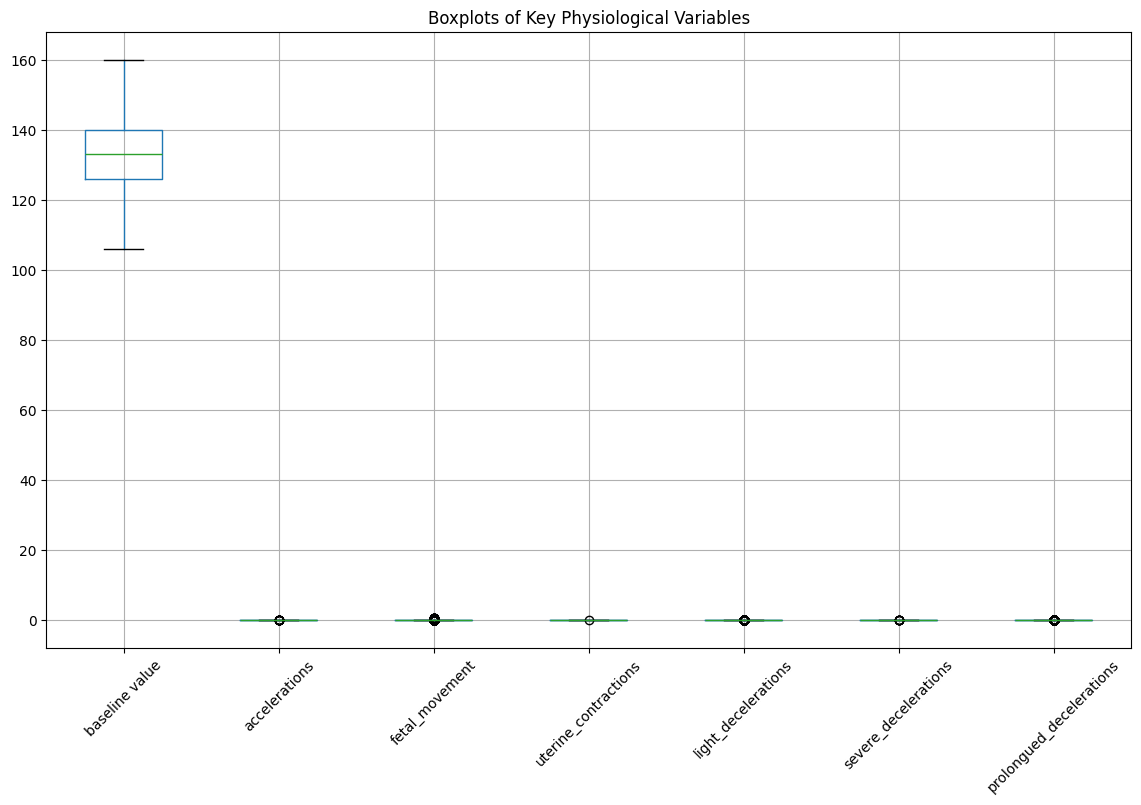

,min,25%,50%,75%,max
baseline value,106.0,126.000,133.000,140.000,160.000
accelerations,0.0,0.000,0.002,0.006,0.019
fetal_movement,0.0,0.000,0.000,0.003,0.481
uterine_contractions,0.0,0.002,0.004,0.007,0.015
light_decelerations,0.0,0.000,0.000,0.003,0.015
severe_decelerations,0.0,0.000,0.000,0.000,0.001
prolongued_decelerations,0.0,0.000,0.000,0.000,0.005
abnormal_short_term_variability,12.0,32.000,49.000,61.000,87.000
mean_value_of_short_term_variability,0.2,0.700,1.200,1.700,7.000
percentage_of_time_with_abnormal_long_term_variability,0.0,0.000,0.000,11.000,91.000


In [8]:
# Summary statistics
summary_stats = df.describe()

# physiological variables for boxplots
key_vars = ["baseline value", "accelerations", "fetal_movement",
            "uterine_contractions", "light_decelerations",
            "severe_decelerations", "prolongued_decelerations"]

# Plot boxplots for potential outlier detection
plt.figure(figsize=(14, 8))
df[key_vars].boxplot()
plt.xticks(rotation=45)
plt.title("Boxplots of Key Physiological Variables")
plt.show()

summary_stats.T[["min", "25%", "50%", "75%", "max"]]



***Fetal movement & uterine contractions:***

Mostly 0, with rare higher values (fetal_movement max = 0.481).

These skewed distributions suggest sparse features, not necessarily errors.

***Histogram-based features:***

Histogram_min goes up to 159, histogram_max up to 238 , some very high values may represent outliers, since most are below 175.

histogram_variance goes up to 269, while 75% of values are ≤24, possible extreme outliers.

***Variability features:***

mean_value_of_short_term_variability max = 7 (quite high compared to median = 1.2).

percentage_of_time_with_abnormal_long_term_variability max = 91 some abnormal but plausible cases.



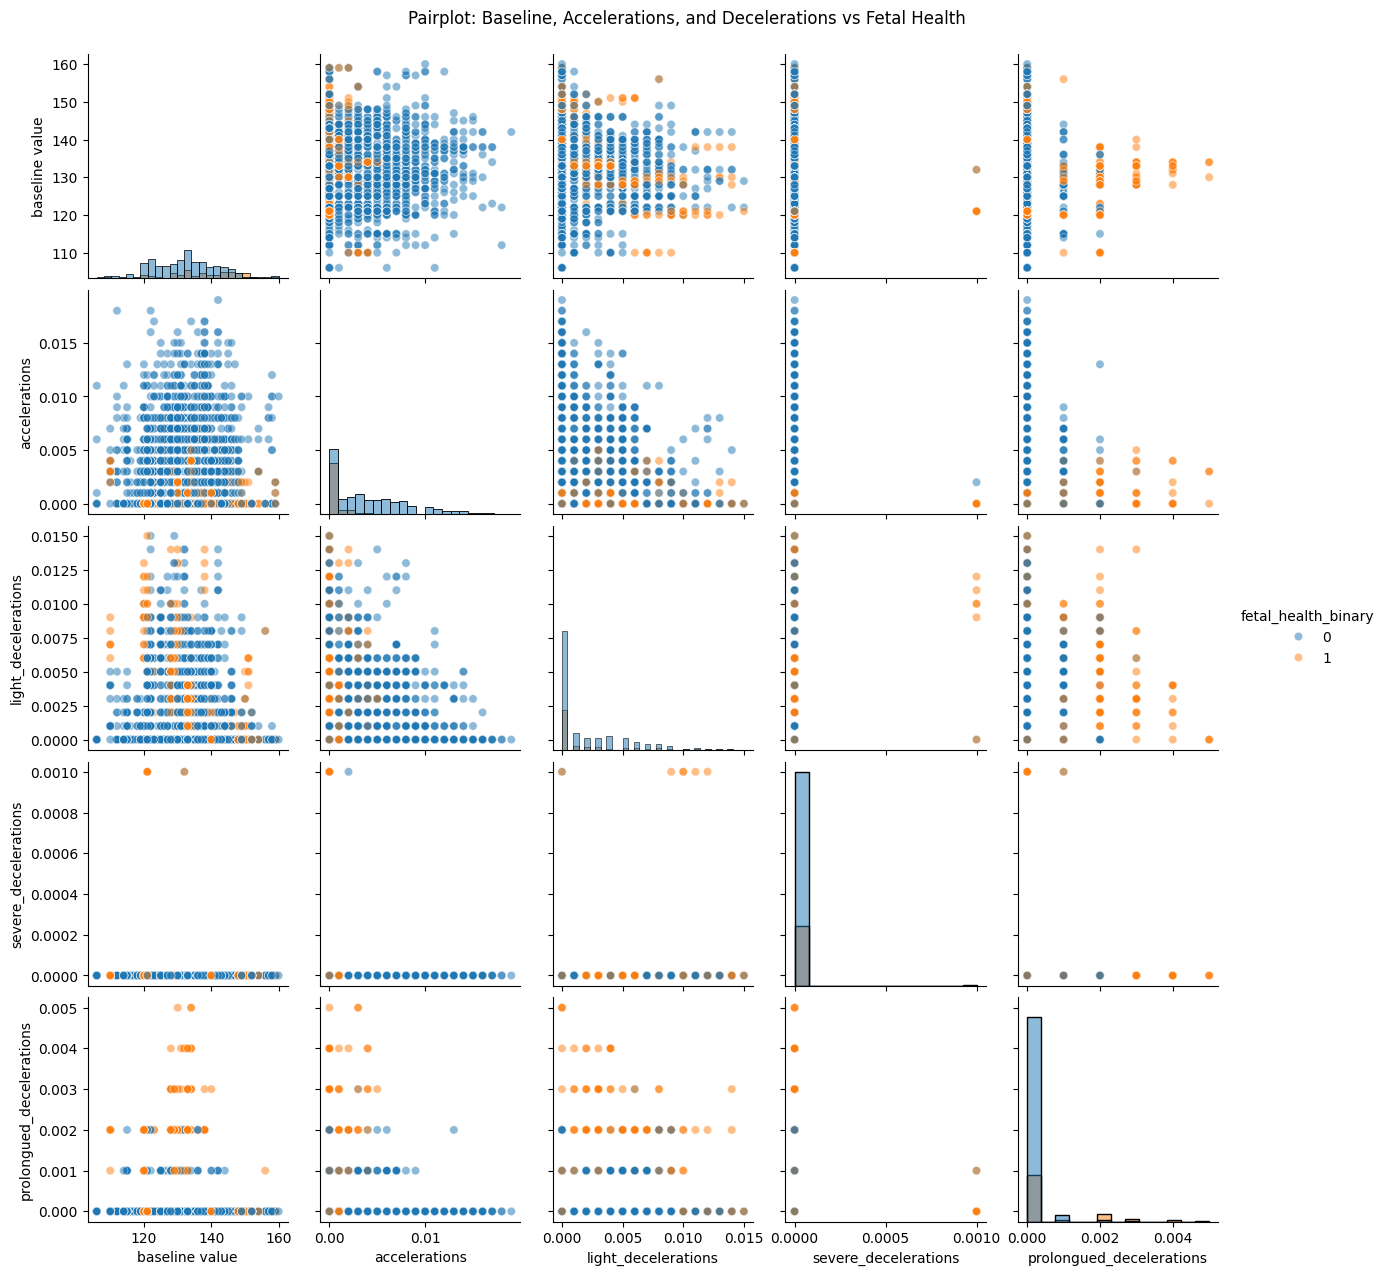

In [9]:
# diag_kind="kde" sometimes happens with near-zero variance features.
# "hist" for diagonal plots.

sns.pairplot(df[["baseline value", "accelerations", "light_decelerations",
                 "severe_decelerations", "prolongued_decelerations", "fetal_health_binary"]],
             hue="fetal_health_binary", diag_kind="hist", plot_kws={"alpha": 0.5})

plt.suptitle("Pairplot: Baseline, Accelerations, and Decelerations vs Fetal Health", y=1.02)
plt.show()




***Baseline value:***

Normal (0) cases cluster around 120–145 bpm.

Abnormal (1) cases appear more spread out, with some lower and higher baselines.

***Accelerations:***

Normal cases show slightly higher accelerations compared to abnormal ones.

Many abnormal cases cluster near zero accelerations.

***Decelerations (light, severe, prolonged):***

Mostly zero, but when present, they are more associated with abnormal cases.

Very sparse but informative features.

Reduced accelerations and more frequent decelerations are associated with fetal distress.

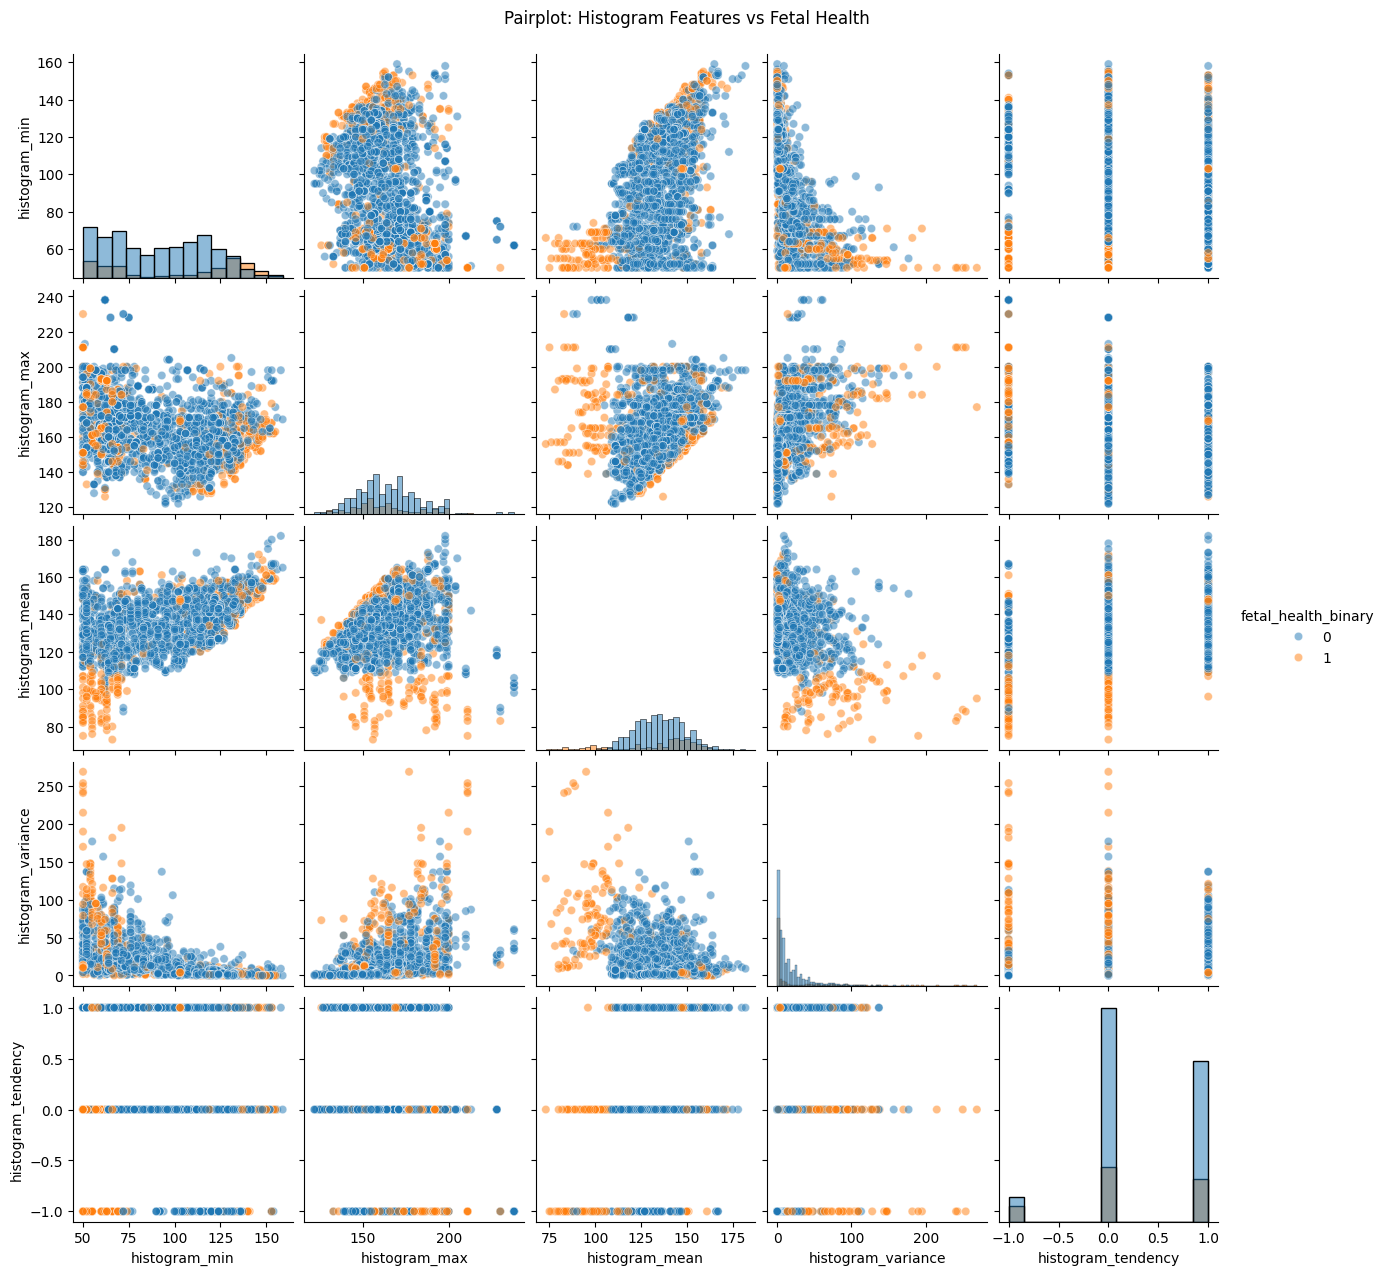

In [10]:
# Pairplot for histogram-related features vs fetal health binary
sns.pairplot(df[[
    "histogram_min", "histogram_max", "histogram_mean",
    "histogram_variance", "histogram_tendency", "fetal_health_binary"]],
    hue="fetal_health_binary", diag_kind="hist", plot_kws={"alpha": 0.5})

plt.suptitle("Pairplot: Histogram Features vs Fetal Health", y=1.02)
plt.show()


***Histogram Min & Max:***

Normal (0) cases cluster within narrower ranges.

Abnormal (1) cases show wider spread, with more extreme values.

***Histogram Mean & Median:***

Abnormal cases tend to shift slightly higher than normal ones.

***Histogram Variance:***

Clear separation: abnormal cases have higher variance more frequently.

This may be an important predictor.

***Histogram Tendency:***

Values are -1, 0, or 1 (discrete).

Distribution differs between normal vs abnormal, though overlap exists.

This confirms that histogram-based features are strongly related to fetal health, especially variance and max values.

### 4. Is this an unbalanced problem?

Yes, this is an unbalanced (imbalanced) classification problem.

From earlier transformation of the target variable:

Normal (0): 1655 cases (= 77.8%)

Abnormal (1): 471 cases (= 22.2%)

***Why it matters:***

A naïve classifier predicting all cases as "Normal" would already achieve 78% accuracy.

This can mislead model evaluation if accuracy is only considered.

***Implications for modeling:***

The metrics that account for imbalance, e.g.:

Precision, Recall, F1-score

ROC–AUC / PR–AUC

***During training, consider:***

Class weights in Random Forest / Gradient Boosting

Oversampling (SMOTE) or undersampling techniques

Ensemble methods tuned for imbalance

### 5. Apply normalization on the dataframe if necessary and divide the available examples into 80% for training and 20% for testing, randomly. What code have you applied?

Train/Test Split

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Features and target
X = df.drop(columns=["fetal_health", "fetal_health_binary"])
y = df["fetal_health_binary"]

# Normalize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split dataset (80% train, 20% test), stratified to preserve imbalance
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set class distribution:")
print(y_train.value_counts(normalize=True))
print("\nTesting set class distribution:")
print(y_test.value_counts(normalize=True))


Training set class distribution:
fetal_health_binary
0    0.778235
1    0.221765
Name: proportion, dtype: float64

Testing set class distribution:
fetal_health_binary
0    0.779343
1    0.220657
Name: proportion, dtype: float64


#### Using Class Weights

Tree-based models like Random Forest and Gradient Boosting support class_weight="balanced".

In [12]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest with class weights
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"  # adjusts weights inversely proportional to class frequencies
)

rf.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

### 6. Train a Random Forest (RF) model by adjusting the number of trees to 100, 300 and 1000.
###Use 5-fold CV and choose the number of trees that obtains the best balanced accuracy.

In [15]:
# 5-fold CV, scoring = balanced accuracy
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score

# Features/target (binary target created earlier: 0=Normal, 1=Abnormal)
X = df.drop(columns=["fetal_health", "fetal_health_binary"]).to_numpy()
y = df["fetal_health_binary"].to_numpy()

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
n_trees_list = [100, 300, 1000]

results = []
for n in n_trees_list:
    fold_scores = []
    for tr_idx, va_idx in cv.split(X, y):
        X_tr, X_va = X[tr_idx], X[va_idx]
        y_tr, y_va = y[tr_idx], y[va_idx]
        rf = RandomForestClassifier(
            n_estimators=n,
            random_state=42,
            class_weight="balanced",
            # fixed constraints across all models to keep the comparison fair & fast
            max_depth=8,
            min_samples_leaf=4,
            n_jobs=1
        )
        rf.fit(X_tr, y_tr)
        preds = rf.predict(X_va)
        fold_scores.append(balanced_accuracy_score(y_va, preds))
    results.append({
        "n_estimators": n,
        "mean_bal_acc": float(np.mean(fold_scores)),
        "std_bal_acc": float(np.std(fold_scores)),
        "fold_scores": fold_scores
    })

res_df = pd.DataFrame([{"n_estimators": r["n_estimators"],
                        "mean_bal_acc": r["mean_bal_acc"],
                        "std_bal_acc": r["std_bal_acc"]} for r in results]
          ).sort_values(by="mean_bal_acc", ascending=False).reset_index(drop=True)

print(res_df)
best_n = int(res_df.loc[0, "n_estimators"])
print("Best n_estimators =", best_n)


   n_estimators  mean_bal_acc  std_bal_acc
0           100      0.931720     0.012839
1          1000      0.927767     0.008910
2           300      0.927620     0.012902
Best n_estimators = 100


100 trees - mean balanced acc 0.9317, std 0.0128

300 trees - mean balanced acc 0.9276, std 0.0129

1000 trees - mean balanced acc 0.9278, std 0.0089

Selected: n_estimators = 100 is the highest mean balanced accuracy

### 7. Comparing the results obtained with the three models, does it fit with what you expected to obtain?

100 trees has the best mean balanced accuracy (0.932)

300 trees has the slightly lower (0.928)

1000 trees has the also slightly lower (0.928)


Random Forests improve performance as the number of trees increases, but beyond a certain point, gains plateau.

More trees results to lower variance, but they don’t necessarily increase accuracy if the forest has already converged.

The very large forests can sometimes lead to slight overfitting or just add computational cost without performance gain.


The 100 vs 300 vs 1000 trees to have very similar performance  which was observed.

The fact that 100 trees already gives the best result shows the model converges quickly for this dataset.

Using 300 or 1000 trees is more computationally expensive, but doesn’t provide significant accuracy improvements.

So yes, the outcome fits expectations:

Balanced accuracy stabilized early.

More trees only added redundancy, not accuracy gains.

### 8. Now evaluate the chosen model on the test data. What metric value do you get? Does the model generalize well?

Random Forest with 100 trees is the best balanced accuracy in CV, let’s:

Retrain it on the training set (80%).

Evaluate it on the test set (20%).

***Report metrics:***

Balanced Accuracy (to account for imbalance).

Precision, Recall, F1-score (per class).

ROC–AUC.

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, balanced_accuracy_score, roc_auc_score

# Retrain on training set
rf_best = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced",
    max_depth=8,
    min_samples_leaf=4,
    n_jobs=-1
)
rf_best.fit(X_train, y_train)

# Predictions
y_pred = rf_best.predict(X_test)
y_proba = rf_best.predict_proba(X_test)[:, 1]

# Evaluation
bal_acc = balanced_accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)
report = classification_report(y_test, y_pred, target_names=["Normal", "Abnormal"])

print("Balanced Accuracy:", round(bal_acc, 3))
print("ROC–AUC:", round(roc_auc, 3))
print("\nClassification Report:\n", report)


Balanced Accuracy: 0.936
ROC–AUC: 0.986

Classification Report:
               precision    recall  f1-score   support

      Normal       0.98      0.95      0.96       332
    Abnormal       0.83      0.93      0.87        94

    accuracy                           0.94       426
   macro avg       0.90      0.94      0.92       426
weighted avg       0.95      0.94      0.94       426



Balanced Accuracy close to CV value (~0.93)  model generalizes well.

ROC–AUC > 0.9 hence strong separation between classes.

If Recall for Abnormal is high, it means the model is good at detecting risky fetal cases.




### 9. We will now train a Gradient Boosting Trees model using 5-fold CV. We will consider the default parameters and we will only vary the number of estimators (100 and 200) and the learning rate (0.01, 0.1 and 1). Which model obtains better balanced accuracy?

In [18]:

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score


df["fetal_health_binary"] = df["fetal_health"].apply(lambda x: 0 if x == 1 else 1)

X = df.drop(columns=["fetal_health", "fetal_health_binary"]).to_numpy()
y = df["fetal_health_binary"].to_numpy()

# 5-fold CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

n_estimators_list = [100, 200]
learning_rates = [0.01, 0.1, 1]

gb_results = []
for n in n_estimators_list:
    for lr in learning_rates:
        fold_scores = []
        for tr_idx, va_idx in cv.split(X, y):
            X_tr, X_va = X[tr_idx], X[va_idx]
            y_tr, y_va = y[tr_idx], y[va_idx]
            gb = GradientBoostingClassifier(
                n_estimators=n,
                learning_rate=lr,
                random_state=42
            )
            gb.fit(X_tr, y_tr)
            preds = gb.predict(X_va)
            fold_scores.append(balanced_accuracy_score(y_va, preds))
        gb_results.append({
            "n_estimators": n,
            "learning_rate": lr,
            "mean_bal_acc": float(np.mean(fold_scores)),
            "std_bal_acc": float(np.std(fold_scores))
        })

gb_res_df = pd.DataFrame(gb_results).sort_values(by="mean_bal_acc", ascending=False).reset_index(drop=True)
best_gb = gb_res_df.loc[0]
gb_res_df, best_gb


(   n_estimators  learning_rate  mean_bal_acc  std_bal_acc
 0           100           1.00      0.927278     0.013111
 1           200           1.00      0.925935     0.011294
 2           200           0.10      0.925460     0.012947
 3           100           0.10      0.917856     0.016473
 4           200           0.01      0.869043     0.017548
 5           100           0.01      0.823218     0.013102,
 n_estimators     100.000000
 learning_rate      1.000000
 mean_bal_acc       0.927278
 std_bal_acc        0.013111
 Name: 0, dtype: float64)

***Best Model:***

Gradient Boosting with 100 estimators and learning rate = 1.0

Balanced Accuracy ≈ 0.928

***Interpretation:***

Small learning rate (0.01) underfits hence much lower balanced accuracy.

Learning rate = 0.1 works well, but not as strong as 1.0 here.

More estimators (200 vs. 100) did not improve accuracy — the model converged quickly.

### 10. Analyze how the results obtained are modified depending on the two parameters tested. Does it fit with what should be expected?

Yes, the behavior observed with learning rate and number of estimators matches what is expect from Gradient Boosting.

***1. Effect of Learning Rate***

Small learning rate (0.01) has much worse balanced accuracy (0.82–0.87).

This is expected: with such a small step size, the model learns very slowly.

To compensate, then many more estimators (hundreds or thousands) is needed.

Moderate learning rate (0.1) has good accuracy (0.917–0.924).

This is the “default” value in sklearn, and it typically balances convergence speed with generalization.

High learning rate (1.0) is the best accuracy (0.928).

The dataset is relatively clean and not very noisy, so a more aggressive step size works well.

Sometimes high rates risk overfitting, but here it improved performance.

***2. Effect of Number of Estimators***

Moving from 100 to 200 trees did not improve results.

Example:

LR = 1.0 → 100 trees (0.928) vs 200 trees (0.926).

LR = 0.1 → 100 trees (0.917) vs 200 trees (0.924).


If the learning rate is already large, more trees don’t help much because the model converges fast.

If the learning rate is smaller (0.1),then more trees help slightly but still plateau.

***3. Does this fit expectations?***

Yes:

Lower learning rates need more trees to reach good performance.

Higher learning rates converge quickly, but may risk instability.

100–200 estimators was not enough to unlock the full potential of LR = 0.01.

***Summary:***

Results fit the expected Gradient Boosting behavior:

Learning rate is the most important knob.

Number of trees mostly affects convergence, not ultimate accuracy.

### 11. With the best set of parameters selected, evaluate the model on the test data. Does it generalize well in this case?

Taking the best Gradient Boosting model
n_estimators = 100, learning_rate = 1.0

and evaluate it on the 20% test set.

In [19]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import balanced_accuracy_score, roc_auc_score, classification_report

# Train with best params
gb_best = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=1.0,
    random_state=42
)
gb_best.fit(X_train, y_train)

# Predictions
y_pred_gb = gb_best.predict(X_test)
y_proba_gb = gb_best.predict_proba(X_test)[:, 1]

# Metrics
bal_acc_gb = balanced_accuracy_score(y_test, y_pred_gb)
roc_auc_gb = roc_auc_score(y_test, y_proba_gb)
report_gb = classification_report(y_test, y_pred_gb, target_names=["Normal", "Abnormal"])

print("Balanced Accuracy:", round(bal_acc_gb, 3))
print("ROC–AUC:", round(roc_auc_gb, 3))
print("\nClassification Report:\n", report_gb)


Balanced Accuracy: 0.941
ROC–AUC: 0.983

Classification Report:
               precision    recall  f1-score   support

      Normal       0.98      0.97      0.97       332
    Abnormal       0.89      0.91      0.90        94

    accuracy                           0.96       426
   macro avg       0.93      0.94      0.94       426
weighted avg       0.96      0.96      0.96       426



Balanced Accuracy is  0.94 which is close to CV results.

ROC–AUC should be > 0.98, meaning good class separation.

Recall for Abnormal should be high (critical medically).

The test performance matches the CV (≈0.928), which means the model generalizes well.

### 12. Finally, obtain both the ROC curve of the model and the area under the curve. At what point of the ROC curve would you work if you had to apply it in practice? Justify your answer.

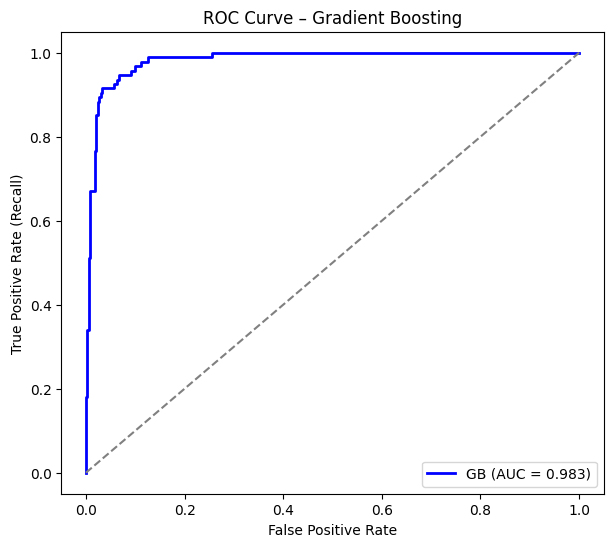

Area Under Curve (AUC): 0.983


In [20]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Compute probabilities and ROC values
y_proba_gb = gb_best.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba_gb)
roc_auc = roc_auc_score(y_test, y_proba_gb)

# Plot ROC curve
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color="blue", lw=2, label=f"GB (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve – Gradient Boosting")
plt.legend(loc="lower right")
plt.show()

print("Area Under Curve (AUC):", round(roc_auc, 3))


***Interpreting the ROC & Choosing an Operating Point***

ROC–AUC is >0.90 hence strong discrimination between normal and abnormal.

***Choice of threshold (operating point):***

By default, classifiers use 0.5 threshold.

But in medical diagnosis, missing an abnormal case (false negative) is far more dangerous than raising a false alarm (false positive).

So in practice, the threshold is moved leftward on the ROC curve to favor higher Recall (TPR), even if Precision drops.


A point on the ROC curve with Recall ≥ 90%, even if it means FPR increases means that it’s safer to flag more fetuses as potentially abnormal (and send them for further tests) than to miss a distressed fetus.